In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
from scipy import spatial
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import musical
warnings.filterwarnings("ignore")

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 6,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
human_3mer = pd.read_csv('data/hg38.3-mer-count.txt', index_col=0, header=None, sep='\t')
human_3mer = human_3mer.to_dict()[1]

Processing function

In [3]:
import json

def read_context_mut_result(file_path):

    result = json.load(open(file_path, 'r'))

    one_mer_context = result['1mer']['context']
    one_mer_variant = result['1mer']['variant']
    three_mer_context = result['3mer']['context']
    three_mer_variant = result['3mer']['variant']

    return one_mer_context, one_mer_variant, three_mer_context, three_mer_variant

def generate_3mer_combinations():
    bases = ['A', 'T', 'C', 'G']
    return [a+b+c for a in bases for b in bases for c in bases]

kmer_list = generate_3mer_combinations()

def get_complementary(kmer):
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement[base] for base in reversed(kmer))

def calculate_3mer_mutation_proportions_correct(three_mer_context, three_mer_variant):
    '''
    Calculate the proportions of mutation mutation_rate_dict for each 3-mer mutation type with whole genome context correction.
    '''
    
    mutation_count_dict = {}
    mutation_rate_dict = {}
    kl = []
    for kmer in kmer_list:
        if kmer[1] in ['C', 'T']:
            kl.append(kmer)

    nuc_list = set(['A', 'T', 'C', 'G'])
    kl = set(kl)
    
    for kmer in kl:
        ref_nuc = kmer[1]
        alt_nucs = nuc_list - set(ref_nuc)

        for alt_nuc in alt_nucs:
            ref_kmer = kmer
            alt_kmer = kmer[:1] + alt_nuc + kmer[2:]

            mutation_density = (
                three_mer_variant[f'{ref_kmer}>{alt_kmer}']['count'] + three_mer_variant[f'{get_complementary(ref_kmer)}>{get_complementary(alt_kmer)}']['count']
            ) / (
                three_mer_context[ref_kmer] + three_mer_context[get_complementary(ref_kmer)] - three_mer_variant[f'{ref_kmer}>{alt_kmer}']['mask'] - three_mer_variant[f'{get_complementary(ref_kmer)}>{get_complementary(alt_kmer)}']['mask']
            )
            mutation_rate = -np.log(1 - mutation_density)

            total_sites = human_3mer[ref_kmer] + human_3mer[get_complementary(ref_kmer)]
            mutation_count_dict[f'MR({ref_kmer}>{alt_kmer}/{get_complementary(ref_kmer)}>{get_complementary(alt_kmer)})'] = mutation_rate * total_sites
            mutation_rate_dict[f'MR({ref_kmer}>{alt_kmer}/{get_complementary(ref_kmer)}>{get_complementary(alt_kmer)})'] = mutation_rate
    
    total_count = sum(mutation_count_dict.values())
    proportions = {k: v / total_count for k, v in mutation_count_dict.items()}

    return proportions


def read_and_process(files, names):
    
    df_dic = {}

    for file, name in zip(files, names):
        _, _, three_mer_context, three_mer_variant = read_context_mut_result(file)
        df_dic[name] = calculate_3mer_mutation_proportions_correct(three_mer_context, three_mer_variant)

    df = pd.DataFrame(df_dic)
    df.columns = names
    df = df.reset_index().melt(id_vars='index')
    df.rename(columns={'index': 'Mutation', 'variable': 'Gene', 'value': 'Value'}, inplace=True)

    df['Mt_type'] = df['Mutation'].apply(lambda x: f"{x[4]}>{x[8]}")
    df['Mt_3mer'] = df.apply(lambda x: f"{x['Mutation'][3:6]}({x['Mt_type']})", axis=1)
    df.sort_values(by=['Mt_type', 'Mt_3mer'], ascending=True, inplace=True)

    return df

In [4]:
def transform_mttype(x):
    return f'{x[0]}[{x[-4:-1]}]{x[2]}'

def generate_mutation_matrix(df, samplenames):

    dfs = []
    for samplename in samplenames:
        sub_df = df[df['Gene'] == samplename]
        sub_df = sub_df[['Mt_3mer', 'Value']]
        dfs.append(sub_df)

    # Initialize the merged dataframe with the first dataframe
    merged_df = dfs[0].rename(columns={'Value': samplenames[0]})[['Mt_3mer', samplenames[0]]]
    merged_df['Mt_3mer'] = merged_df['Mt_3mer'].apply(transform_mttype)
    
    # Merge subsequent dataframes
    for df, sample in zip(dfs[1:], samplenames[1:]):
        df = df.rename(columns={'Value': sample})
        df['Mt_3mer'] = df['Mt_3mer'].apply(transform_mttype)
        merged_df = pd.merge(merged_df, df[['Mt_3mer', sample]], on='Mt_3mer', how='outer')
    
    # Save the merged dataframe to the specified CSV file
    merged_df = merged_df.rename(columns={'Mt_3mer': 'Mutation Types'})
    return merged_df

In [5]:
def get_scaled_mutation_spectrum(file):
    '''
    Plot the scaled mutation spectrum for each sample.
    '''
    
    _, _, three_mer_context, three_mer_variant = read_context_mut_result(file)
    
    mutation_count_dict = {}
    threemer_count_dict = {}
    kl = []
    for kmer in kmer_list:
        if kmer[1] in ['C', 'T']:
            kl.append(kmer)

    nuc_list = set(['A', 'T', 'C', 'G'])
    kl = set(kl)

    for kmer in kl:
        ref_nuc = kmer[1]
        alt_nucs = nuc_list - set(ref_nuc)

        threemer_count_dict[f'{kmer}/{get_complementary(kmer)}'] = human_3mer[kmer] + human_3mer[get_complementary(kmer)]
        for alt_nuc in alt_nucs:
            ref_kmer = kmer
            alt_kmer = kmer[:1] + alt_nuc + kmer[2:]

            mutation_density = (
                three_mer_variant[f'{ref_kmer}>{alt_kmer}']['count'] + three_mer_variant[f'{get_complementary(ref_kmer)}>{get_complementary(alt_kmer)}']['count']
            ) / (
                three_mer_context[ref_kmer] + three_mer_context[get_complementary(ref_kmer)] - three_mer_variant[f'{ref_kmer}>{alt_kmer}']['mask'] - three_mer_variant[f'{get_complementary(ref_kmer)}>{get_complementary(alt_kmer)}']['mask']
            )
            mutation_rate = -np.log(1 - mutation_density)
            total_sites = human_3mer[ref_kmer] + human_3mer[get_complementary(ref_kmer)]
            mutation_count_dict[f'{ref_kmer}>{alt_kmer}/{get_complementary(ref_kmer)}>{get_complementary(alt_kmer)}'] = mutation_rate * total_sites

    total_count = sum(mutation_count_dict.values())
    proportions = {k: v / total_count for k, v in mutation_count_dict.items()}

    return proportions, threemer_count_dict

Plot spectrum

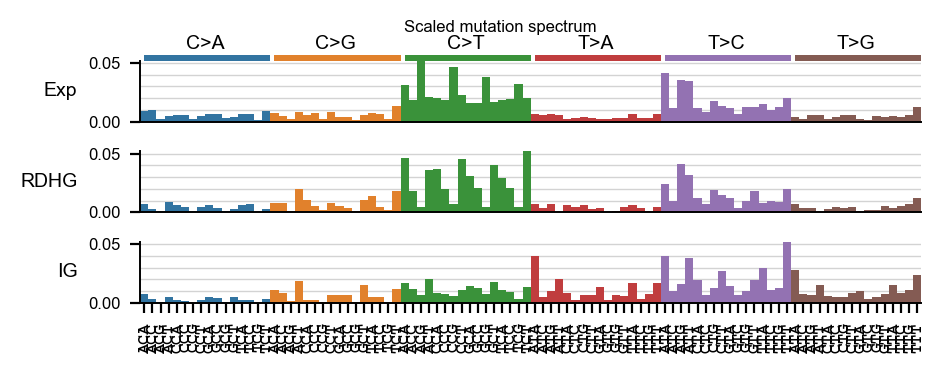

In [6]:
%matplotlib inline

PATH = "data/variant_count"

GENE_GROUP = [
    "hg38.gencodeV44.Lecluze_sperm_expdata.express_gene",
    "hg38.gencodeV44.repli-dep-histone",
    "hg38.gencodeV44.immunoglobulin",
]

GENE_NAME = [
    "ExpGene",
    "RDH",
    "IG",
]

VARIANT_SET = "gnomAD_5e-3"
REGION = 'transcript'
species = 'Human'

files = [
    os.path.join(PATH, f"{gene_group}_{REGION}_{VARIANT_SET}.result") for gene_group in GENE_GROUP
]

fig, axes = plt.subplots(
    nrows=len(GENE_NAME), ncols=1, figsize=(4.7, 0.65 * len(GENE_NAME)),
    sharex=True
)

for i, file in enumerate(files):

    threemer_proportions, threemer_count_dict = get_scaled_mutation_spectrum(file)
    # Sort
    threemer_count_dict = {k: v/sum(threemer_count_dict.values()) for k, v in threemer_count_dict.items()}

    df = pd.DataFrame.from_dict(threemer_proportions, orient='index', columns=['Value'])
    df = df.reset_index()
    df.rename(columns={'index': 'Mutation', 'value': 'Value'}, inplace=True)

    df['Mt_type'] = df['Mutation'].apply(lambda x: f"{x[1]}>{x[5]}")
    df['Mt_3mer'] = df.apply(lambda x: f"{x['Mutation'][0:3]}({x['Mt_type']})", axis=1)
    df.sort_values(by=['Mt_type', 'Mt_3mer'], ascending=True, inplace=True)

    sns.barplot(ax=axes[i], x='Mt_3mer', y='Value', hue='Mt_type', data=df, width=1,
                linewidth=0, edgecolor='black')

    ax_lengend_color = axes[i].get_legend_handles_labels()[0]
    legend_colors = [patch.get_facecolor() for patch in ax_lengend_color]

    axes[i].set_title('')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].legend_.remove()

for ax in axes:
    ax.spines[[
        'top', 'right'
    ]].set_visible(False)
    ax.grid(False)
    ax.set_ylim(0, 0.052)
    ax.yaxis.label.set_size(6)

    for y_tick in np.arange(0.01, 0.06, 0.01):
        ax.axhline(y=y_tick, color='lightgrey', linewidth=0.5, zorder=-1)

# Rotate x-tick labels
xticks = axes[-1].get_xticklabels()
axes[-1].set_xticklabels([tick.get_text().split('(')[0] for tick in xticks],
                         fontsize=6,
                         fontdict={
                            'family': 'Courier',
                            'weight': 'bold',
                         })
axes[-1].tick_params(
    axis='x', rotation=90,
)

for start in np.arange(0, 6, 1):

    rect = patches.Rectangle(
        (start/6 + 1/96/2, 1),      
        1/6 - 1/96/2, 0.1,    
        # linewidth=0.7,
        # edgecolor='black',
        facecolor=legend_colors[start],
        transform=axes[0].transAxes,
        clip_on=False
    )
    axes[0].add_patch(rect)
   
    axes[0].text(
        start/6 + 1/12, 1.12, 
        f"{['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G'][start]}",
        ha='center', va='bottom',
        transform=axes[0].transAxes,
        fontsize=7,
        fontdict={
            'family': 'Arial',
        }
    )

for ax in axes[0:-1]:
    ax.xaxis.set_visible(False)

for idx, label in enumerate(['Exp', 'RDHG', 'IG']):
    axes[idx].set_ylabel(
        label,
        rotation=0, 
        ha='right', 
        va='center',
        fontsize=7
    )
fig.suptitle('Scaled mutation spectrum', y=0.9, x=0.53)

plt.tight_layout()

In [7]:
PATH = "data/variant_count"
FILE = [
    "hg38.gencodeV44.Lecluze_sperm_expdata.express_gene",
    "hg38.gencodeV44.Lecluze_sperm_expdata.unexpress_gene",
    "hg38.gencodeV44.repli-indep-histone",
    "hg38.gencodeV44.repli-dep-histone",
    "hg38.gencodeV44.immunoglobulin",
]
GENE_NAME = [
    "ExpGene",
    "UnexpGene",
    "RIH",
    "RDH",
    "Ig",
]
variant_name = "gnomAD_5e-3"
DATASET = [variant_name] * len(FILE)
REGION = 'transcript'
FILENAME = 'hg38.gene_mt_matrix.incluConflict.'
files=[os.path.join(PATH, f"{file}_{REGION}_{dataset}.result") for file, dataset in zip(FILE, DATASET)]

df = read_and_process(
    files=files,
    names=GENE_NAME
)

total_variant_count = [sum([info['count'] for info in read_context_mut_result(i)[3].values()]) for i in files]

mutation_matrix = generate_mutation_matrix(df, GENE_NAME)
for idx, col in enumerate(mutation_matrix.columns[1:]):
    mutation_matrix[col] = mutation_matrix[col] * total_variant_count[idx]

mutation_matrix.to_csv(f'data/variant_count/hg38.gene_mt_matrix.incluConflict.{variant_name.replace("gnomAD_", "")}.{REGION}.txt', index=False, sep="\t")

MuSiCal refit

In [8]:
class Signature:

    def __init__(self, spec_path, sig_dict, exclude_cpg=False, thresh=0.005):
        self.H = {}
        self.cos_sim = {}
        self.samplename = {}
        self.X_reconstructed = {}
        self.X = pd.read_csv(spec_path, sep='\t', index_col=0)
        if exclude_cpg:
            self.X = self.X.loc[~self.X.index.str.contains('[C>T]G', regex=False)]

        for key, path in sig_dict.items():
            W = pd.read_csv(path, sep='\t', index_col=0)
            W = W.loc[self.X.index]
            X = self.X.reindex(W.index)
            H, model = musical.refit.refit(X, W, method='likelihood_bidirectional', connected_sigs=True, thresh=thresh)
            self.H[key] = H
            self.cos_sim[key] = model.cos_similarities
            self.X_reconstructed[key] = model.X_reconstructed
            self.samplename[key] = H.columns.tolist()
    
    def summary_cs(self, df=True):
        if df:
            data = []
            for sig, cs_list in self.cos_sim.items():
                sp_list = self.samplename[sig]
                for sp, cs in zip(sp_list, cs_list):
                    data.append([sig, sp, cs])
            
            df = pd.DataFrame(data, columns=["Signature", "Sample", "Cosine Similarity"])
            pivot_df = df.pivot(index='Signature', columns='Sample', values='Cosine Similarity')
            return pivot_df
        else:
            for sig, cs_list in self.cos_sim.items():
                sp_list = self.samplename[sig]
                for sp, cs in zip(sp_list, cs_list):
                    print(f'{sig}\t{sp}\t{cs:.4f}')

    def get_composition(self, sig):
        df = self.H[sig]
        df = df.div(df.sum(axis=0), axis=1)
        return df

In [9]:
variant = "5e-3"
region = "transcript"

fit_situ_dic = {
    'SBS1&5 (base)': 'data/COSMIC_sig/SBS1_SBS5.txt',
    'base&AID/APOBEC': 'data/COSMIC_sig/SBS1_SBS2ss*_SBS5_SBS9_SBS13_SBS84_SBS85.txt',
    'All SBSs': 'data/COSMIC_sig/COSMIC_sigs.txt',
}

sigfit_result = Signature(f'data/variant_count/hg38.gene_mt_matrix.incluConflict.{variant}.{region}.txt', fit_situ_dic, thresh=0.005)

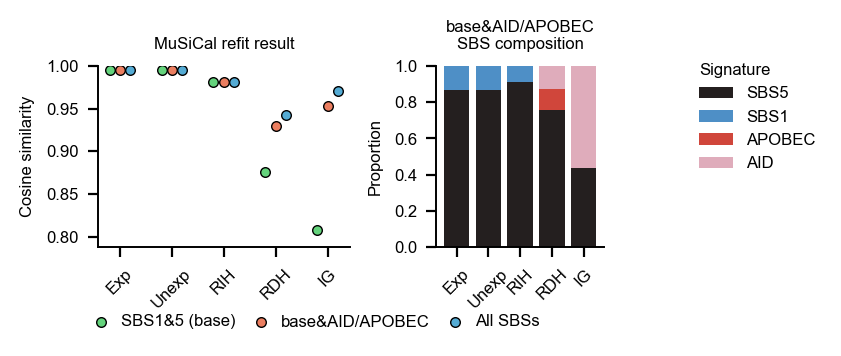

In [10]:
%matplotlib inline

custom_colors = ['#64D37C', '#EB7E60', '#54ABD4'] 
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=custom_colors)

fig, axes = plt.subplots(1, 2, figsize=(3.1, 1.4), width_ratios=[1.5, 1])
sig_combs = fit_situ_dic.keys()
sample_name = np.array(list(sigfit_result.samplename.values())[0])
offset = np.linspace(-0.2, 0.2, len(sig_combs))

show_lst = [0, 1, 2, 3, 4]
x = range(len(sample_name[show_lst]))

for i, sig_comb in enumerate(sig_combs):
    axes[0].scatter(
        [xi + offset[i] for xi in x], np.array(sigfit_result.cos_sim[sig_comb])[show_lst], label=sig_comb,
        s=12, edgecolors='black', linewidth=0.5
    )

axes[0].set_ylabel('Cosine similarity')
ymin = axes[0].get_ylim()[0]
axes[0].set_ylim(ymin-0.01, 1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(sample_name[show_lst])

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), 
           ncol=3, frameon=False,
           handletextpad=0.2, columnspacing=0.5,
          )

axes[0].set_title(f'MuSiCal refit result')
axes[0].spines[['top', 'right']].set_visible(False)

# Custom colors for the SBS signatures
custom_colors = {
    'SBS5': '#241F1F',
    'SBS1': '#4E8FC6',
    'SBS2ss*': '#D0463B',
    'SBS13': '#D0463B',
    'SBS9': '#DFACBB',
    'SBS84': '#DFACBB',
    'SBS85': '#DFACBB' 
}
label_dic = {
    'SBS5': 'SBS5',
    'SBS1': 'SBS1',
    'SBS2ss*': 'APOBEC',
    'SBS13': 'APOBEC',
    'SBS9': 'AID',
    'SBS84': 'AID',
    'SBS85': 'AID'
}

H = sigfit_result.H[list(fit_situ_dic.keys())[1]]
data = H.div(H.sum(axis=0), axis=1)
labels = []
data = data.iloc[:, show_lst]
bottom = np.zeros(len(data.columns))
for sig in custom_colors.keys():
    row = data.loc[sig].tolist()
    if label_dic[sig] not in labels:
        axes[1].bar(data.columns, row, bottom=bottom, color=custom_colors[sig], label=label_dic[sig])
        labels.append(label_dic[sig])
    else:
        axes[1].bar(data.columns, row, bottom=bottom, color=custom_colors[sig])
    bottom += row

axes[1].set_ylabel('Proportion')

fig.tight_layout()
axes[1].legend(loc='upper right', frameon=False,
            bbox_transform=axes[1].transAxes, bbox_to_anchor=(2.35, 1.1),
            title='Signature', alignment='left')

for ax in axes:
    ax.xaxis.set_ticklabels(
        [
            'Exp', 'Unexp', 'RIH', 'RDH', 'IG'
        ], rotation=45
    )

axes[1].set_title(f'{list(fit_situ_dic.keys())[1]}\nSBS composition')
axes[1].spines[['top', 'right']].set_visible(False)